In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import glob
from concurrent.futures import ThreadPoolExecutor
import os

# define functions

In [77]:
def plot_degree_distribution(coauthorship_graph, output_folder, output_prefix):
    degrees = [d for _, d in coauthorship_graph.degree()]
    
    plt.figure(figsize=(10, 6))
    
    ## Plot 1: Log-log plot
    plt.subplot(1, 2, 1)
    #count how often each degree is present
    degree_counts = {}
    for d in degrees:
        if d in degree_counts:
            degree_counts[d] += 1
        else:
            degree_counts[d] = 1
    
    #convert to lists for plotting
    unique_degrees = sorted(degree_counts.keys())
    frequencies = [degree_counts[d] for d in unique_degrees]
    
    plt.loglog(unique_degrees, frequencies, 'o', markersize=4, color='blue')
    plt.title("Log-Log Degree Distribution")
    plt.xlabel("Degree (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.grid(True, which="both", ls="--", alpha=0.7)
    
    ## Plot 2: Histogram with log scale on y-axis
    plt.subplot(1, 2, 2)
    plt.hist(degrees, bins=range(min(degrees), max(degrees) + 1), 
             edgecolor="black", color="lightblue", alpha=0.7, log=True)
    plt.title("Degree Distribution (Log Scale)")
    plt.xlabel("Degree (Number of co-authors)")
    plt.ylabel("Frequency (log scale)")
    plt.xlim(left=0)
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.7)
    
    plt.tight_layout()
    
    #save
    output_file = f"{output_folder}/{output_prefix}_degree_distribution_log.png"
    plt.savefig(output_file)
    plt.show()

In [78]:
def plot_degree_centrality_by_gender(coauthorship_graph, authors_df, output_folder, output_prefix):

    degree_centrality = dict(coauthorship_graph.degree(weight="weight"))

    author_gender = {
        (row["LastName"], row["ForeName"]): row["Gender"]
        for _, row in authors_df.iterrows()
    }

    centrality_by_gender = defaultdict(list)
    for author, centrality in degree_centrality.items():
        gender = author_gender.get(author, "unknown")
        centrality_by_gender[gender].append(centrality)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for gender in sorted(centrality_by_gender, key=lambda g: g != 'male'):
        centralities = centrality_by_gender[gender]
        axes[0].hist(
            centralities, bins=20, alpha=0.7,
            label=gender, color=gender_colors.get(gender, 'black')
        )

    axes[0].set_title("Degree Centrality by Gender (Linear Scale)")
    axes[0].set_xlabel("Degree Centrality")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()
    axes[0].set_xlim(left=0)
    axes[0].grid(True)

    for gender in sorted(centrality_by_gender, key=lambda g: g != 'male'):
        centralities = centrality_by_gender[gender]
        non_zero_centralities = [c for c in centralities if c > 0]
        if non_zero_centralities:
            axes[1].hist(
                non_zero_centralities, bins=20, alpha=0.7,
                label=gender, color=gender_colors.get(gender, 'black')
            )

    axes[1].set_title("Degree Centrality by Gender (Log-X Scale)")
    axes[1].set_xlabel("Degree Centrality")
    axes[1].set_ylabel("Frequency")
    axes[1].set_xscale('log')
    axes[1].legend()
    axes[1].grid(True)

    for gender in sorted(centrality_by_gender, key=lambda g: g != 'male'):
        centralities = centrality_by_gender[gender]
        non_zero_centralities = [c for c in centralities if c > 0]
        if non_zero_centralities:
            hist, bins = np.histogram(non_zero_centralities, bins=20)
            logbins = np.logspace(np.log10(min(non_zero_centralities)),
                                  np.log10(max(non_zero_centralities)),
                                  20)
            hist_log, _ = np.histogram(non_zero_centralities, bins=logbins)
            bin_centers = 0.5 * (logbins[1:] + logbins[:-1])

            axes[2].scatter(bin_centers, hist_log + 0.1,
                           label=gender, color=gender_colors.get(gender, 'black'),
                           alpha=0.7)
            axes[2].plot(bin_centers, hist_log + 0.1,
                        color=gender_colors.get(gender, 'black'),
                        alpha=0.5)

    axes[2].set_title("Degree Centrality by Gender (Log-Log Scale)")
    axes[2].set_xlabel("Degree Centrality")
    axes[2].set_ylabel("Frequency")
    axes[2].set_xscale('log')
    axes[2].set_yscale('log')
    axes[2].legend()
    axes[2].grid(True, which="both", ls="-")

    plt.tight_layout()

    os.makedirs(output_folder, exist_ok=True)
    output_file = f"{output_folder}/{output_prefix}_degree_centrality_by_gender_log_scales.png"
    plt.savefig(output_file)
    plt.show()

    return centrality_by_gender

In [79]:
def external_internal_index(coauthorship_graph, authors_df):
    author_gender = {
        (row["LastName"], row["ForeName"]): row["Gender"]
        for _, row in authors_df.iterrows()
    }

    external_weight = 0
    internal_weight = 0

    for u, v, data in coauthorship_graph.edges(data=True):
        weight = data.get("weight", 1)
        gender_u = author_gender.get(u, None)
        gender_v = author_gender.get(v, None)

        if gender_u != gender_v:
            external_weight += weight
        else:
            internal_weight += weight

    total_weight = external_weight + internal_weight
    return external_weight / total_weight if total_weight > 0 else 0

In [80]:
def newman_gender_assortativity(coauthorship_graph, authors_df):
    
    author_gender = {
        (row["LastName"], row["ForeName"]): row["Gender"]
        for _, row in authors_df.iterrows()
    }

    nx.set_node_attributes(coauthorship_graph, author_gender, "gender")

    assortativity = nx.attribute_assortativity_coefficient(coauthorship_graph, "gender")

    return assortativity

# everything in one function

In [ ]:
def analyze_csv(authors_df, disease, output_folder="output", output_prefix="metrics"):

    filtered_authors = authors_df[(authors_df["Gender"] == 'male') | (authors_df["Gender"] == 'female')]
    
    filtered_authors_df = filtered_authors[filtered_authors["Mention"] == disease]

    if filtered_authors_df.empty:
        print(f"No data for {disease}. Skipping...")
        return

    import collections
    coauthorship_graph = nx.Graph()
    grouped_authors = filtered_authors_df.groupby("PMID")

    #create all nodes
    for _, row in filtered_authors_df.iterrows():
        coauthorship_graph.add_node((row["LastName"], row["ForeName"]), gender=row["Gender"])

    #count co-authorships and set them as edge weights
    edge_weights = collections.defaultdict(int)
    for _, group in grouped_authors:
        authors = group[["LastName", "ForeName"]].apply(tuple, axis=1).tolist()
        for pair in itertools.combinations(authors, 2):
            edge_weights[pair] += 1

    for (u, v), w in edge_weights.items():
        coauthorship_graph.add_edge(u, v, weight=w)

    os.makedirs(output_folder, exist_ok=True)
    graph_file_path = os.path.join(output_folder, f"{output_prefix}_coauthorship.graphml")
    nx.write_graphml(coauthorship_graph, graph_file_path)

    plot_degree_distribution(coauthorship_graph, output_folder, output_prefix)

    centrality_by_gender = plot_degree_centrality_by_gender(coauthorship_graph, filtered_authors_df, output_folder, output_prefix)

    ei_index = external_internal_index(coauthorship_graph, authors_df)
    print(f"External-Internal Index for {disease}: {ei_index:.4f}")

    gender_assortativity = newman_gender_assortativity(coauthorship_graph, authors_df)
    print(f"Newman Gender Assortativity Index for {disease}: {gender_assortativity:.4f}")

    stats_file = f"{output_folder}/{output_prefix}_{disease}_indices.txt"
    with open(stats_file, "w") as f:
        f.write(f"External-Internal Index: {ei_index:.4f}\n")
        f.write(f"Newman Gender Homophily Index: {gender_assortativity:.4f}\n")

    return centrality_by_gender


## function for boxplot gender centrality

In [82]:
def create_centrality_boxplots_by_decade(centrality_data_dict, output_folder="output", disease_name="prostate"):
    #filter  None values and empty dictionaries
    filtered_centrality_data = {k: v for k, v in centrality_data_dict.items() 
                                 if v is not None and v}
    
    male_data = []
    female_data = []
    time_periods = []
    
    #sort chronologically
    for decade, centrality_dict in sorted(filtered_centrality_data.items()):
        #male data
        if centrality_dict.get('male'):
            male_data.append(centrality_dict['male'])
            time_periods.append(str(decade))
        
        #female data
        if centrality_dict.get('female'):
            female_data.append(centrality_dict['female'])
    
    plt.figure(figsize=(14, 8))
    
    #dynamically adjust positions based on actual data
    positions = np.arange(max(len(male_data), len(female_data))) * 3
    male_positions = positions
    female_positions = positions + 0.8
    width = 0.8
    
    #gender colors
    gender_colors = {
        'male': 'darkorchid',
        'female': 'darkorange'
    }
    
    #plot male data
    if male_data:
        male_bp = plt.boxplot(male_data, positions=male_positions[:len(male_data)], 
                               widths=width, patch_artist=True, 
                               boxprops=dict(facecolor=gender_colors['male'], alpha=0.7))
    
    #plot female data
    if female_data:
        female_bp = plt.boxplot(female_data, positions=female_positions[:len(female_data)], 
                                 widths=width, patch_artist=True, 
                                 boxprops=dict(facecolor=gender_colors['female'], alpha=0.7))
    
    legend_elements = []
    legend_labels = []
    if male_data:
        legend_elements.append(male_bp["boxes"][0])
        legend_labels.append('Male')
    if female_data:
        legend_elements.append(female_bp["boxes"][0])
        legend_labels.append('Female')
    
    if legend_elements:
        plt.legend(legend_elements, legend_labels, loc='upper right')
    
    display_periods = time_periods[:max(len(male_data), len(female_data))]
    plt.xticks(positions + width/2, display_periods, rotation=45)
    
    plt.xlabel('Decade')
    plt.ylabel('Degree Centrality')
    plt.title(f'Degree Centrality by Gender Across Decades - {disease_name.title()}')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    #save
    os.makedirs(output_folder, exist_ok=True)
    output_file = f"{output_folder}/{disease_name}_degree_centrality_by_gender_across_decades.png"
    plt.savefig(output_file, bbox_inches='tight')
    plt.show()
    plt.close()  #free memory
    
    #statistics
    summary_stats = []
    
    for i, period in enumerate(display_periods):
        #male
        if i < len(male_data):
            male_stats = {
                'Decade': period,
                'Gender': 'male',
                'Count': len(male_data[i]),
                'Mean': np.mean(male_data[i]),
                'Median': np.median(male_data[i]),
                'Min': np.min(male_data[i]),
                'Max': np.max(male_data[i]),
                'Std': np.std(male_data[i])
            }
            summary_stats.append(male_stats)
        
        #female
        if i < len(female_data):
            female_stats = {
                'Decade': period,
                'Gender': 'female',
                'Count': len(female_data[i]),
                'Mean': np.mean(female_data[i]),
                'Median': np.median(female_data[i]),
                'Min': np.min(female_data[i]),
                'Max': np.max(female_data[i]),
                'Std': np.std(female_data[i])
            }
            summary_stats.append(female_stats)
    
    #save
    if summary_stats:
        stats_file = f"{output_folder}/{disease_name}_centrality_gender_stats_by_decade.csv"
        pd.DataFrame(summary_stats).to_csv(stats_file, index=False)
    else:
        print(f"No summary statistics available for {disease_name}")

# prostate cancer

In [83]:
disease = "prostate" 
output_prefix = "prostate"
output_folder = "gender_analysis"

# gender colors
gender_colors = {
    'male': 'darkorchid',
    'female': 'darkorange',
    'unknown': 'darkgray'
}

authors_df = pd.read_csv('authors_gendered.csv')

/tmp/ipykernel_57169/1639513977.py:12: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  authors_df = pd.read_csv('authors_gendered.csv')


In [84]:
authors_df

,PMID,DescriptorName_UI,LastName,ForeName,AID,Journal_JournalIssue_PubDate_Year,Gender
0,11584014,D011471,Blumberg,Peter,3687806,2002.0,male
1,11584014,D011471,Fujii,Teruhiko,6757189,2002.0,male
2,11584014,D011471,Han,Kee-Chung,1683011,2002.0,unknown
3,11584014,D011471,Kazanietz,Marcelo,1988542,2002.0,male
4,11584014,D011471,Kuroki,Toshio,2419118,2002.0,male
...,...,...,...,...,...,...,...
493733,33243732,D001943,Xu,Xianwei,10476437,2020.0,male
493734,33243732,D001943,Xu,Xiaoyan,2595498,2020.0,female
493735,33243732,D001943,Yang,Jinhua,13370892,2020.0,female
493736,33245928,D001943,Funtan,Anne,18498376,2021.0,female


Processing split_authors_2000-2010.csv...


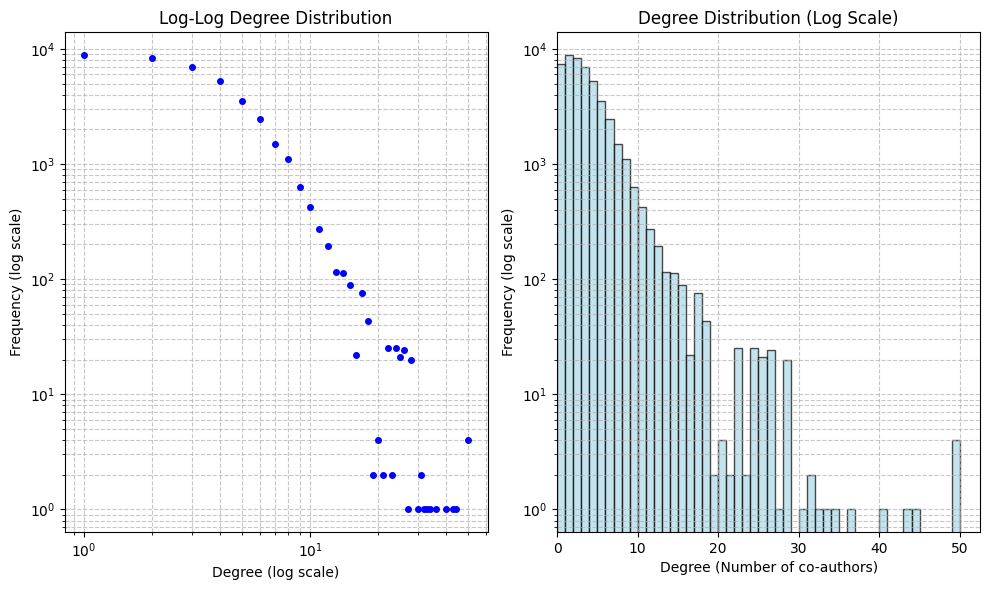

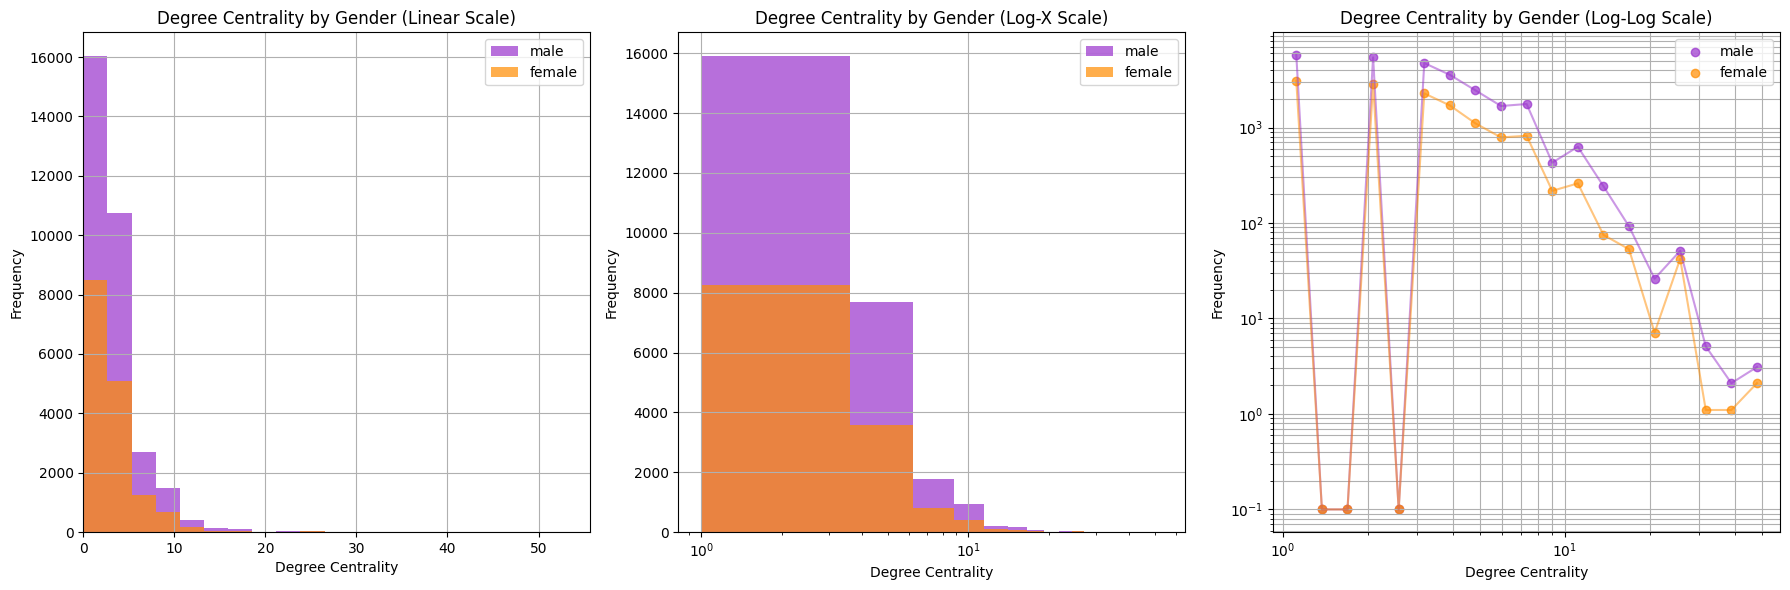

External-Internal Index for prostate: 0.3884
Newman Gender Assortativity Index for prostate: 0.1122
Processing split_authors_2010-2020.csv...


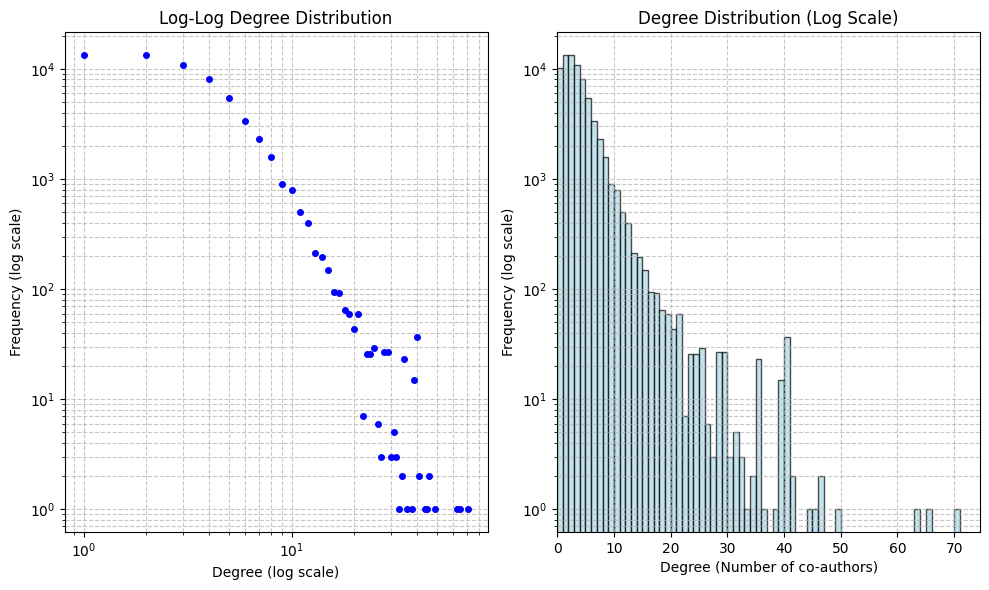

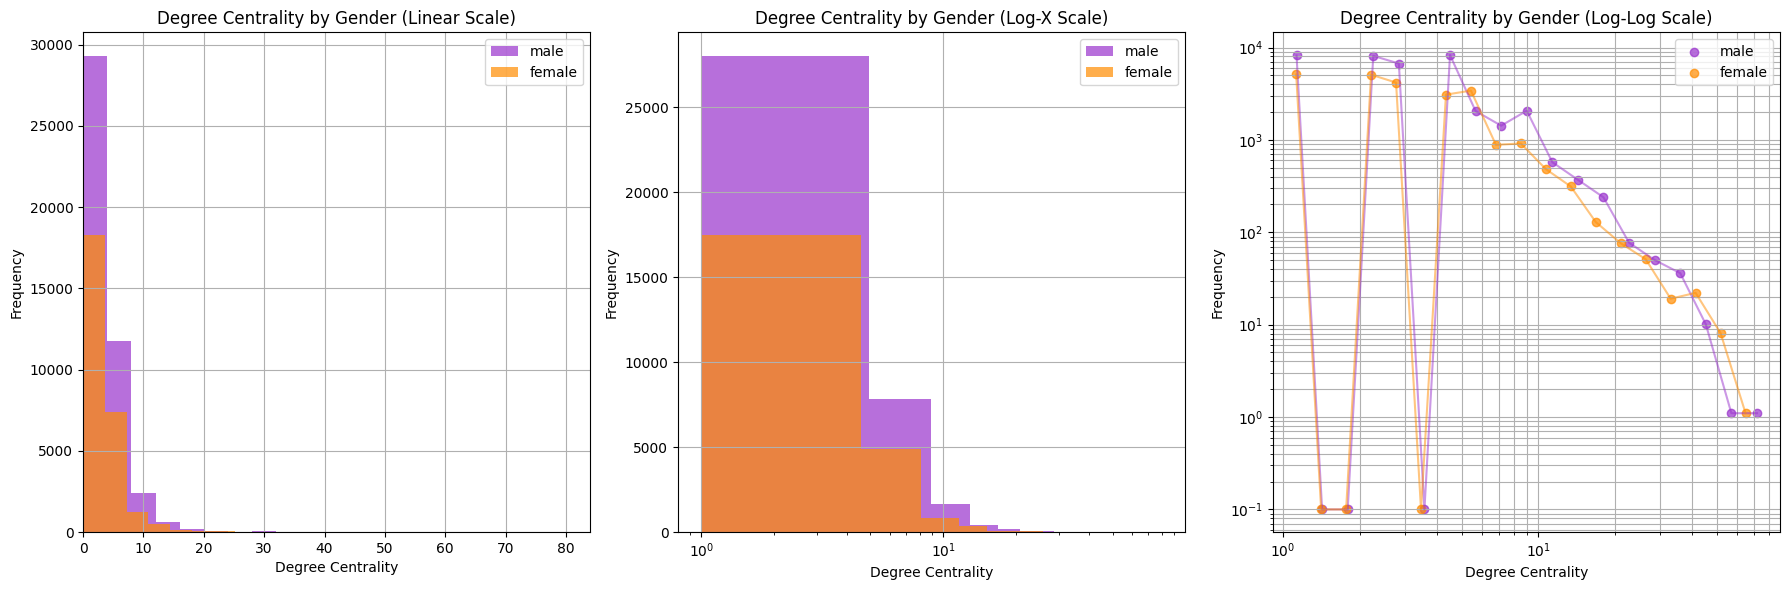

External-Internal Index for prostate: 0.4251
Newman Gender Assortativity Index for prostate: 0.0996


In [85]:
#dictionary to store centrality data for each decade
centrality_data_dict = {}

#all csv files
csv_files = sorted(glob.glob("split_authors_*.csv"))

for csv_file in csv_files:
    print(f"Processing {csv_file}...")
    
    file_decade = csv_file.split('/')[-1].replace('.csv', '')
    
    authors_df = pd.read_csv(csv_file)
    
    output_prefix = f"prostate_{file_decade}"
    
    centrality_by_gender = analyze_csv(authors_df, disease=disease, output_folder=output_folder, output_prefix=output_prefix)
    
    #store centrality data for boxplot
    centrality_data_dict[output_prefix] = centrality_by_gender

### boxplots of degree centrality

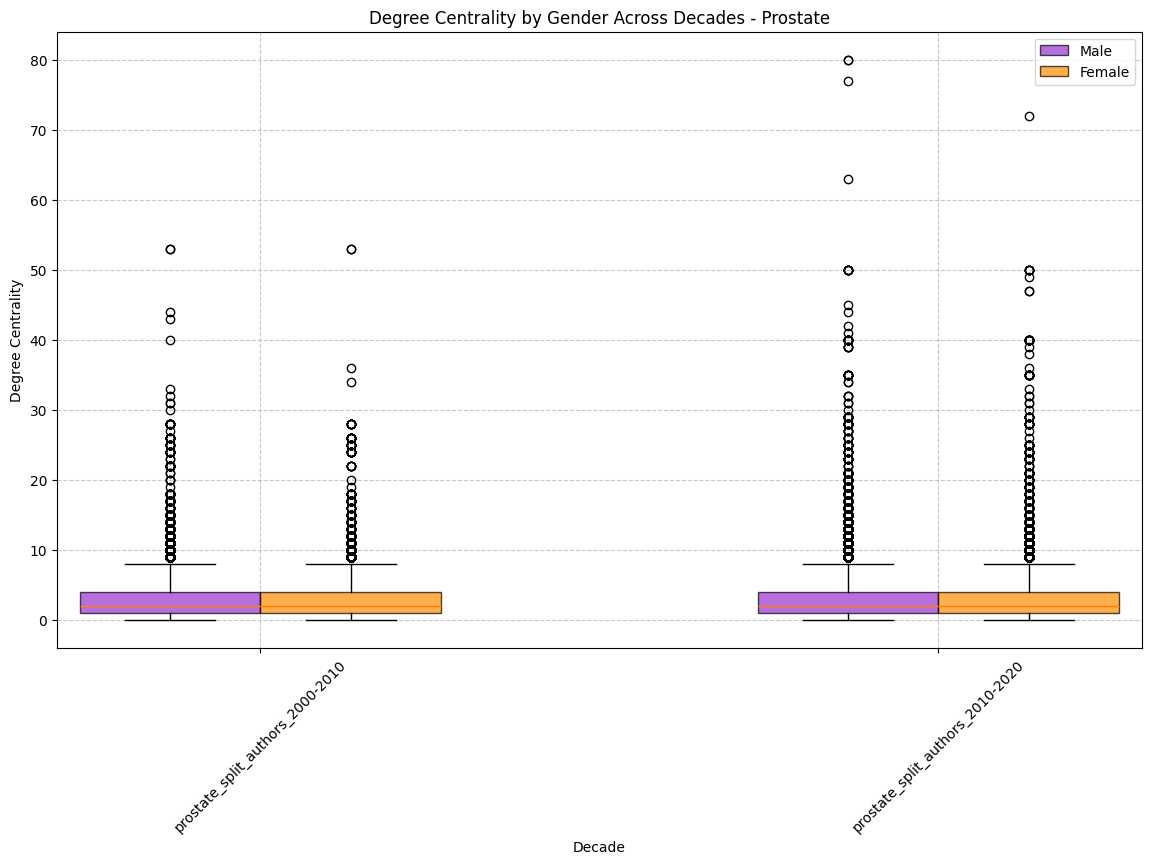

In [86]:
#remove None
filtered_centrality_data = {k: v for k, v in centrality_data_dict.items() if v is not None}
create_centrality_boxplots_by_decade(filtered_centrality_data, output_folder=output_folder, disease_name="prostate")

# breast

In [87]:
disease = "breast" 
output_prefix = "breast"
output_folder = "gender_analysis"

# gender colors
gender_colors = {
    'male': 'darkorchid',
    'female': 'darkorange',
}
authors_df = pd.read_csv('authors_gendered.csv')

/tmp/ipykernel_57169/1735627272.py:10: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  authors_df = pd.read_csv('authors_gendered.csv')


Processing split_authors_2000-2010.csv...


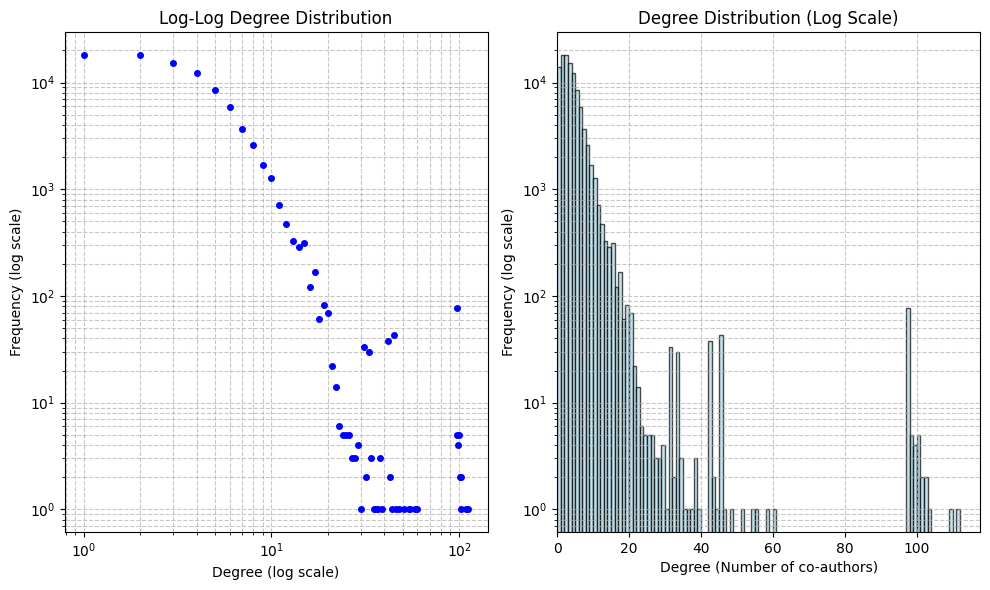

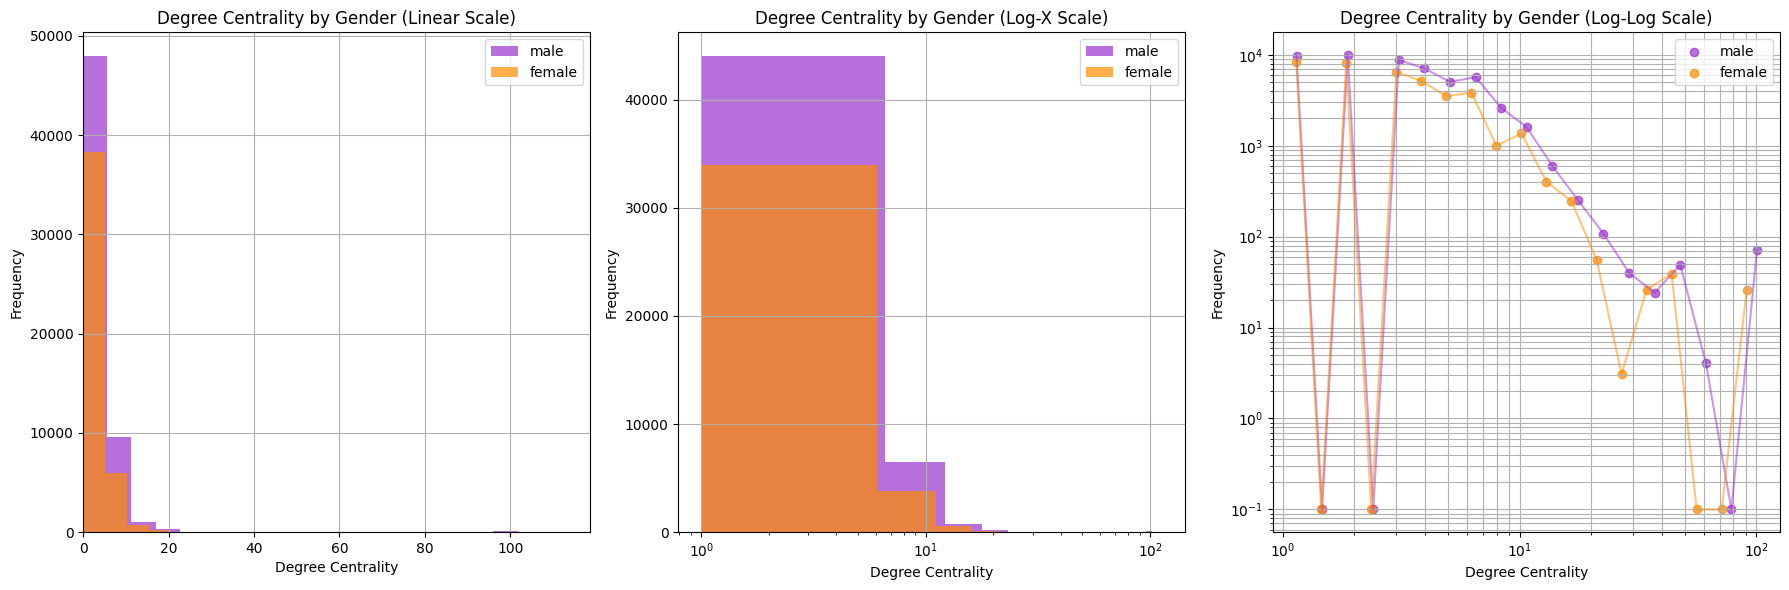

External-Internal Index for breast: 0.4226
Newman Gender Assortativity Index for breast: 0.1224
Processing split_authors_2010-2020.csv...


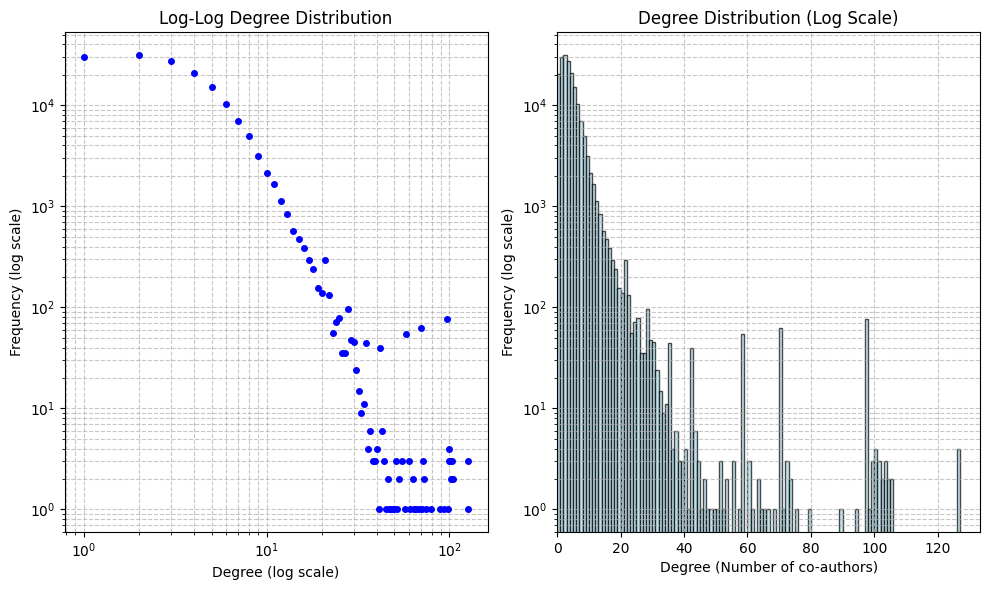

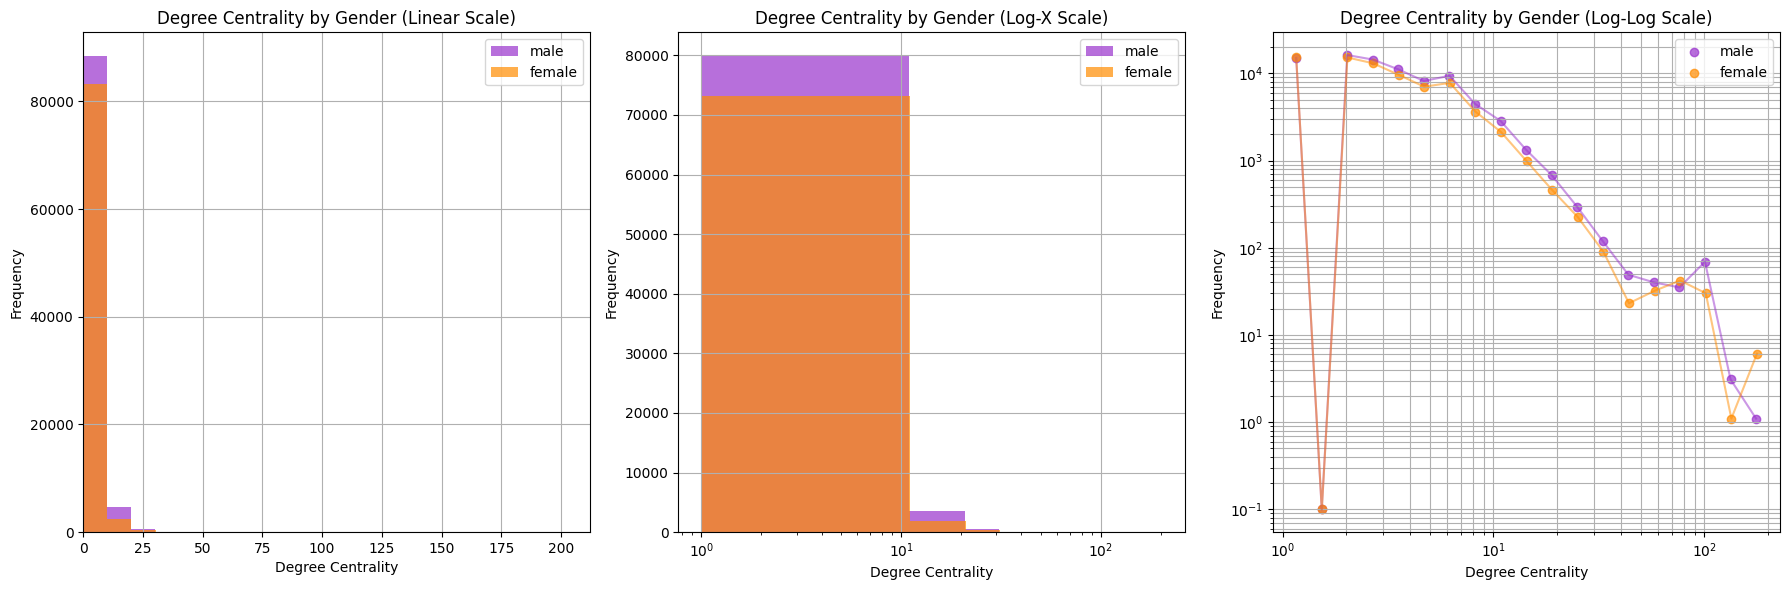

External-Internal Index for breast: 0.4469
Newman Gender Assortativity Index for breast: 0.0978


In [88]:
#dictionary to store centrality data for each decade
centrality_data_dict = {}

#all csv files
csv_files = sorted(glob.glob("split_authors_*.csv"))

for csv_file in csv_files:
    print(f"Processing {csv_file}...")
    
    file_decade = csv_file.split('/')[-1].replace('.csv', '')
    
    authors_df = pd.read_csv(csv_file)
    
    output_prefix = f"breast_{file_decade}"
    
    centrality_by_gender = analyze_csv(authors_df, disease=disease, output_folder=output_folder, output_prefix=output_prefix)
    
    #store centrality data for boxplot
    if centrality_by_gender:
        centrality_data_dict[output_prefix] = centrality_by_gender

### boxplots of degree centrality

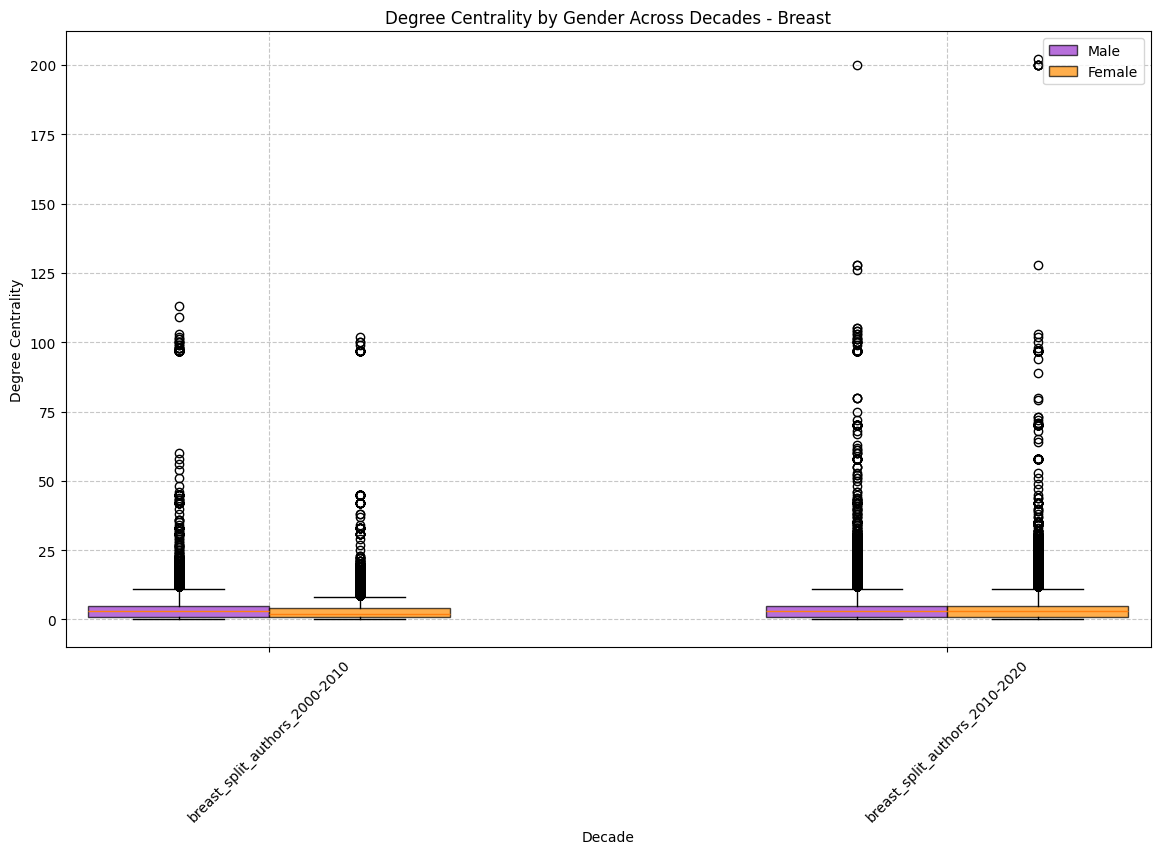

In [89]:
#remove None
filtered_centrality_data = {k: v for k, v in centrality_data_dict.items() if v is not None}
create_centrality_boxplots_by_decade(filtered_centrality_data, output_folder=output_folder, disease_name="breast")